In [1]:
import os
import numpy as np
from PIL import Image

import torch
from torch.utils.data import Dataset

In [2]:
class SegmentationDataset(Dataset):
    def __init__(self, auth_img_dir, forged_img_dir, forged_mask_dir, target_size = (256, 320)):
        self.samples = []
        self.target_size = target_size

        for img in os.listdir(auth_img_dir):
            if img.lower().endswith((".jpg", ".png", ".jpeg")):
                self.samples.append({
                    "image_path": os.path.join(auth_img_dir, img),
                    "mask_path": None,
                    "type": "authentic"
                })

        for img in os.listdir(forged_img_dir):
            if img.lower().endswith((".jpg", ".png", ".jpeg")):
                self.samples.append({
                    "image_path": os.path.join(forged_img_dir, img),
                    "mask_path": os.path.join(
                        forged_mask_dir,
                        os.path.splitext(img)[0] + ".npy"
                    ),
                    "type": "forged"
                })

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        sample = self.samples[idx]

        image = Image.open(sample["image_path"]).convert("RGB")
        image = image.resize((self.target_size[1], self.target_size[0]))
        image = np.array(image, dtype=np.float32) / 255.0

        height, width, _ = image.shape

        if sample["type"] == "authentic":
            mask = np.zeros((height, width), dtype=np.float32)

        else:
            mask = np.load(sample["mask_path"]).astype(np.float32)

            if mask.ndim == 3:
                mask = mask[0]

            mask = (mask > 0).astype(np.float32)

            mask = Image.fromarray(mask)
            mask = mask.resize((self.target_size[1], self.target_size[0]), Image.NEAREST)
            mask = np.array(mask, dtype = np.float32)


        image = np.transpose(image, (2, 0, 1))   # C × H × W
        mask = np.expand_dims(mask, axis=0)      # 1 × H × W

        image = torch.from_numpy(image)
        mask = torch.from_numpy(mask)

        return image, mask



In [3]:
auth_img_dir = "../data/train_images/authentic"
forged_img_dir = "../data/train_images/forged"
forged_mask_dir = "../data/train_masks"


dataset = SegmentationDataset(auth_img_dir, forged_img_dir, forged_mask_dir )

In [4]:
from torch.utils.data import random_split, DataLoader

dataset_size = len(dataset)
val_size = int(0.2 * dataset_size)
train_size = dataset_size - val_size

train_dataset, val_dataset = random_split(
    dataset, [train_size, val_size]
)

train_loader = DataLoader(
    train_dataset, 
    batch_size=4,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=4,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

In [5]:
images, masks = next(iter(train_loader))
print(images.shape)
print(masks.shape)
print("Positive pixels in batch", masks.sum().item())

torch.Size([4, 3, 256, 320])
torch.Size([4, 1, 256, 320])
Positive pixels in batch 14573.0


In [6]:
import torch
import torch.nn as nn
import torchvision.models as models

class VGGEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        vgg = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)
        self.features = nn.Sequential(*vgg.features[:23])

    def forward(self, x):
        return self.features(x)

In [7]:
encoder = VGGEncoder()
x = torch.randn(1, 3, 320, 256)
f = encoder(x)
print(f.shape)

torch.Size([1, 512, 40, 32])


In [8]:
import torch
import torch.nn as nn

class SimpleDecoder(nn.Module):
    def __init__(self):
        super().__init__()

        self.up1 = nn.Sequential(
            nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False),
            nn.Conv2d(512, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True)
        )

        self.up2 = nn.Sequential(
            nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False),
            nn.Conv2d(256, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True)
        )

        self.up3 = nn.Sequential(
            nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False),
            nn.Conv2d(128, 32, kernel_size=3, padding=1),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        x = self.up1(x)
        x = self.up2(x)
        x = self.up3(x)
        return x

In [9]:
class ManiDet(nn.Module):
    def __init__(self, encoder):
        super().__init__()

        self.encoder = encoder
        self.decoder = SimpleDecoder()
        self.classifier = nn.Conv2d(32, 1, kernel_size=1)

    def forward(self, x):
        f = self.encoder(x)
        d = self.decoder(f)
        out = torch.sigmoid(self.classifier(d))
        return out, d


In [12]:
encoder_mani = VGGEncoder()
manidet = ManiDet(encoder_mani)

x = torch.randn(1, 3, 320, 256)
y = manidet(x)

print("Input: ", x.shape)
print("Output: ", y.shape)

Input:  torch.Size([1, 3, 320, 256])


AttributeError: 'tuple' object has no attribute 'shape'

In [13]:
class SimiDetEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = VGGEncoder()

    def forward(self, x):
        return self.encoder(x)
    
    

In [14]:
simi_enc = SimiDetEncoder()
x = torch.randn(1, 3, 320, 256)
f = simi_enc(x)
print(f.shape)

torch.Size([1, 512, 40, 32])


In [15]:
class selfCorrelation(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x):
        """
        x: (B, C, H, W)
        return: (B, C, W, H*W)
        """

        B, C, H, W = x.shape

        # Flatten spatial dimensions
        x_flat = x.view(B, C, H * W)

        # Normalize features (important)
        x_flat = x_flat - x_flat.mean(dim=1, keepdim=True)
        x_flat = x_flat / (x_flat.std(dim=1, keepdim = True) + 1e-6)

        #Transpose to (B, HW, C)
        x_flat = x_flat.permute(0, 2, 1)

        #Correlation: (B, HW, HW)
        corr = torch.matmul(x_flat, x_flat.transpose(1, 2))

        #Reshape to (B, H, W, HW)
        corr = corr.view(B, H, W, H * W)

        return corr

In [16]:
corr_layer = selfCorrelation()
x = torch.randn(1, 512, 40, 32)
c = corr_layer(x)
print(c.shape)

torch.Size([1, 40, 32, 1280])


In [17]:
class PercentilePooling(nn.Module):
    def __init__(self, K=64):
        super().__init__()
        self.K = K

    def forward(self, x):
        """
        x: (B, H, W, H*W)
        return: (B, K, H, W)
        """

        B, H, W, L = x.shape  # L = H*W = 1280

        # Flatten spatial dims
        x = x.view(B, H * W, L)  # (B, HW, HW)

        # Sort similarities (descneding)
        x_sorted, _ = torch.sort(x, dim=-1, descending=True)

        # Select K evenly spaced percentiles
        idx = torch.linspace(
            0, L - 1, self.K, device=x.device
        ).long()

        pooled = x_sorted[:, :, idx] # (B, HW, K)

        # Restore spatial grid
        pooled = pooled.permute(0, 2, 1).contiguous()
        pooled = pooled.view(B, self.K, H, W)

        return pooled



In [18]:
pp = PercentilePooling(K=64)

x = torch.randn(1, 40, 32, 1280)
y = pp(x)

print(y.shape)

torch.Size([1, 64, 40, 32])


In [19]:
class SimiDecoder(nn.Module):
    def __init__(self):
        super().__init__()

        self.up1 = nn.Sequential(
            nn.Upsample(scale_factor=2, mode="bilinear", align_corners = False),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True)
        )

        self.up2 = nn.Sequential(
            nn.Upsample(scale_factor=2, mode="bilinear", align_corners = False),
            nn.Conv2d(128, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True)
        )

        self.up3 = nn.Sequential(
            nn.Upsample(scale_factor=2, mode="bilinear", align_corners = False),
            nn.Conv2d(64, 32, kernel_size=3, padding=1),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        x = self.up1(x)
        x = self.up2(x)
        x = self.up3(x)
        return x
        

In [20]:
class SimiDet(nn.Module):
    def __init__(self, encoder):
        super().__init__()
        self.encoder = encoder     #separate instance from Mani-Det
        self.corr = selfCorrelation()
        self.pool = PercentilePooling(K=64)
        self.decoder = SimiDecoder()
        self.classifier = nn.Conv2d(32, 1, kernel_size=1)

    def forward (self, x):
        f = self.encoder(x)
        c = self.corr(f)
        p = self.pool(c)
        d = self.decoder(p)
        out = torch.sigmoid(self.classifier(d))
        return out, d  # return features for fusion

In [21]:
encoder_simi = VGGEncoder()
simidet = SimiDet(encoder_simi)

x = torch.randn(1, 3, 320, 256)
y, feat = simidet(x)

print("Output mask: ", y.shape)
print("Decoder feat: ", feat.shape)

Output mask:  torch.Size([1, 1, 320, 256])
Decoder feat:  torch.Size([1, 32, 320, 256])


In [22]:
class Fusion(nn.Module):
    def __init__(self):
        super().__init__()

        self.fuse = nn.Sequential(
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 32, kernel_size=3, padding=1),
            nn.ReLU(inplace=True)
        )

        self.classifier = nn.Conv2d(32, 1, kernel_size=1)

    def forward(self, dm, ds):
        """
        dm: Mani-Det decoder features (B, 64, H, W)
        ds: Simi-Det decoder features (B, 32, H, W)
        """

        x = torch.cat([dm, ds], dim=1)  # (B, 64, H, W)
        x = self.fuse(x)
        out = torch.sigmoid(self.classifier(x))
        return out

In [23]:
class BusterNet(nn.Module):
    def __init__(self):
        super().__init__()

        # Separate encoders
        encoder_mani = VGGEncoder()
        encoder_simi = VGGEncoder()

        self.mani = ManiDet(encoder_mani)
        self.simi = SimiDet(encoder_simi)
        self.fusion = Fusion()

    def forward(self, x):
        _, dm = self.mani(x)
        _, ds = self.simi(x)

        out = self.fusion(dm, ds)
        return out

In [24]:
model = BusterNet()

x = torch.randn(1,3, 320, 256)
y = model(x)

print("Final output:", y.shape)

Final output: torch.Size([1, 1, 320, 256])


In [26]:
class ConditionalDiceLoss(nn.Module):
    def __init__(self, eps=1e-6):
        super().__init__()
        self.eps = eps

    def forward(self, logits, targets):
        probs = torch.sigmoid(logits)

        B = probs.shape[0]
        losses = []

        for i in range(B):
            p = probs[i]
            y = targets[i]

            y_sum = y.sum()

            if y_sum > 0:
                intersection = (p * y).sum()
                union = p.sum() + y_sum
                dice = (2 * intersection + self.eps) / (union + self.eps)
                loss = 1 - dice
            
            else:
                loss = p.mean()

            losses.append(loss)
        
        return torch.stack(losses).mean()

In [27]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = BusterNet().to(device)

criterion = ConditionalDiceLoss()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

In [28]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    running_loss = 0.0

    for images, masks in loader:
        images = images.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        outputs = model(images)
        assert outputs.shape == masks.shape

        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    return running_loss / len(loader)


In [29]:
def validate_one_epoch(model, loader, criterion):
    model.eval()
    running_loss = 0.0

    with torch.no_grad():
        for images, masks in loader:
            images = images.to(device, non_blocking=True)
            masks = masks.to(device, non_blocking=True)

            outputs = model(images)
            assert outputs.shape == masks.shape

            loss = criterion(outputs, masks)
            running_loss += loss.item()

    return running_loss / len(loader)


In [75]:
num_epochs = 5

for epoch in range(num_epochs):
    train_loss = train_one_epoch(
        model, train_loader, optimizer, criterion
    )

    val_loss = validate_one_epoch(
        model, val_loader, criterion
    )

    print(
        f"Epoch [{epoch+1}/{num_epochs}] | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f}"
    )


Epoch [1/5] | Train Loss: 0.7289 | Val Loss: 0.7158
Epoch [2/5] | Train Loss: 0.7287 | Val Loss: 0.7158
Epoch [3/5] | Train Loss: 0.7287 | Val Loss: 0.7158
Epoch [4/5] | Train Loss: 0.7287 | Val Loss: 0.7158
Epoch [5/5] | Train Loss: 0.7288 | Val Loss: 0.7158


In [32]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

def compute_similarity_stat(model, loader, device):
    model.eval()
    similarities = []

    with torch.no_grad():
        for images, masks in loader:
            images = images.to(device)
            masks = masks.to(device)

            feats = model.mani.encoder(images)
            B, C, H, W = feats.shape
            N = H * W

            f = feats.view(B, C, N)
            f_t = f.permute(0, 2, 1)

            sim = torch.bmm(f_t, f)
            sim_max = sim.max(dim=-1)[0]

            similarities.append(sim_max.cpu().numpy())

            break


    similarities = np.concatenate(similarities, axis=1)
    plt.hist(similarities.flatten(), bins=100)
    plt.title("Max Similarity Distribution")
    plt.show

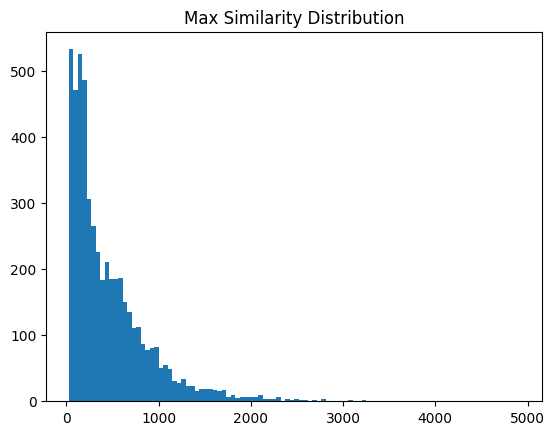

In [33]:
similarities = compute_similarity_stat(model, train_loader, device)



In [34]:
def compute_similarity_pos_neg(encoder, loader, device):
    encoder.eval()

    pos_sims = []
    neg_sims = []

    with torch.no_grad():
        for images, masks in loader:
            images = images.to(device)
            masks = masks.to(device)

            feats = encoder(images)
            B, C, H, W = feats.shape
            N = H * W

            f = feats.view(B, C, N)
            f_t = f.permute(0, 2, 1)

            sim = torch.bmm(f_t, f)
            sim_max = sim.max(dim=-1)[0]  # (B, N)

            masks_resized = F.interpolate(
                masks.float(),
                size=(H, W),
                mode="nearest"
            ).view(B, N)

            for b in range(B):
                pos = sim_max[b][masks_resized[b] > 0]
                neg = sim_max[b][masks_resized[b] == 0]

                if len(pos) > 0:
                    pos_sims.append(pos.cpu().numpy())
                neg_sims.append(neg.cpu().numpy())

            break

    pos_sims = np.concatenate(pos_sims) if len(pos_sims) > 0 else np.array([])
    neg_sims = np.concatenate(neg_sims)

    return pos_sims, neg_sims


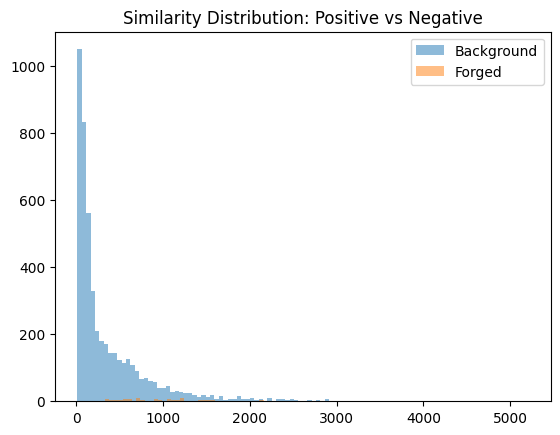

In [36]:
encoder_mani = encoder_mani.to(device)
pos_sims, neg_sims = compute_similarity_pos_neg(encoder_mani, train_loader, device)

plt.hist(neg_sims, bins=100, alpha=0.5, label='Background')
plt.hist(pos_sims, bins=100, alpha=0.5, label='Forged')
plt.legend()
plt.title("Similarity Distribution: Positive vs Negative")
plt.show()


In [41]:
def compute_offset_consistency(encoder, loader, device):
    encoder.eval()
    offset_magnitudes = []

    with torch.no_grad():
        for images, masks in loader:
            images = images.to(device)
            masks = masks.to(device)

            feats = encoder(images)
            B, C, H, W = feats.shape
            N = H * W

            f = feats.view(B, C, N)
            f_t = f.permute(0, 2, 1)

            sim = torch.bmm(f_t, f)

            eye = torch.eye(N).to(device)
            sim = sim - 1e9 * eye.unsqueeze(0)

            idx = sim.argmax(dim=-1)


            coords = torch.arange(N).to(device)
            coords = coords.unsqueeze(0).expand(B, -1)

            offsets = (idx - coords).abs().float()

            masks_resized = F.interpolate(
                masks.float(),
                size=(H, W),
                mode="nearest"
            ).view(B, N)

            for b in range(B):
                pos_offsets = offsets[b][masks_resized[b] > 0]
                if len(pos_offsets) > 0:
                    offset_magnitudes.append(pos_offsets.cpu().numpy())

            # stop once we collected enough data
            if len(offset_magnitudes) > 5:
                break

    if len(offset_magnitudes) == 0:
        print("No forged pixels found at encoder resolution.")
        return None

    offset_magnitudes = np.concatenate(offset_magnitudes)
    return offset_magnitudes


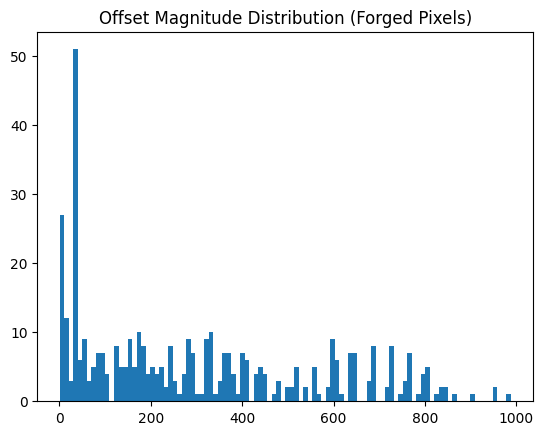

In [42]:
offsets = compute_offset_consistency(encoder_mani, train_loader, device)

plt.hist(offsets, bins=100)
plt.title("Offset Magnitude Distribution (Forged Pixels)")
plt.show()
